In [1]:
print("Hello world")

Hello world


In [2]:
import geopandas as gpd
import pandas as pd

In [5]:
dz = gpd.read_file("data/DZ2021.shp")

In [6]:
dz.head()

,DZ2021_cd,DZ2021_nm,SDZ2021_cd,SDZ2021_nm,DEA2014_cd,DEA2014_nm,LGD2014_cd,LGD2014_nm,Area_ha,Perim_km,geometry
0,N20000001,Dunsilly_A1,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,2070.68,22.93,"POLYGON ((319580.264 396993.361, 319573.665 39..."
1,N20000002,Dunsilly_B1,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1253.69,19.14,"POLYGON ((323772.447 393378.876, 323764.289 39..."
2,N20000003,Dunsilly_A2,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,792.91,15.50,"POLYGON ((305377.841 395055.242, 305378.841 39..."
3,N20000004,Dunsilly_A3,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1100.52,17.90,"POLYGON ((311500.959 395028.333, 311510.728 39..."
4,N20000005,Dunsilly_B2,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1740.82,21.93,"POLYGON ((323772.447 393378.876, 323784.201 39..."


In [8]:
pop = pd.read_excel("data/census-2021-ms-a01.xlsx")

In [9]:
pop.head()

,Unnamed: 0,Unnamed: 1
0,National Statistics Theme:,Census 2021
1,Data subset:,Demography
2,Dataset title:,Usual resident population MS-A01
3,Coverage:,"Data Zone, Super Data Zone, Settlement, Ward, ..."
4,Source:,NISRA


In [10]:
pop = pd.read_excel(
    "data/census-2021-ms-a01.xlsx",
    sheet_name="DZ",
    skiprows=5
)

pop.head()

,Geography,Geography Code,All usual residents,Access census area explorer
0,Dunsilly_A1,N20000001,738,Dunsilly_A1 DZ profile
1,Dunsilly_B1,N20000002,331,Dunsilly_B1 DZ profile
2,Dunsilly_A2,N20000003,365,Dunsilly_A2 DZ profile
3,Dunsilly_A3,N20000004,663,Dunsilly_A3 DZ profile
4,Dunsilly_B2,N20000005,676,Dunsilly_B2 DZ profile


In [11]:
dz.columns

Index(['DZ2021_cd', 'DZ2021_nm', 'SDZ2021_cd', 'SDZ2021_nm', 'DEA2014_cd',
       'DEA2014_nm', 'LGD2014_cd', 'LGD2014_nm', 'Area_ha', 'Perim_km',
       'geometry'],
      dtype='str')

In [12]:
pop.columns

Index(['Geography', 'Geography Code', 'All usual residents',
       'Access census area explorer'],
      dtype='str')

In [13]:
dz = dz.merge(
    pop,
    left_on="DZ2021_cd",
    right_on="Geography Code"
)

In [14]:
dz.head()

,DZ2021_cd,DZ2021_nm,SDZ2021_cd,SDZ2021_nm,DEA2014_cd,DEA2014_nm,LGD2014_cd,LGD2014_nm,Area_ha,Perim_km,geometry,Geography,Geography Code,All usual residents,Access census area explorer
0,N20000001,Dunsilly_A1,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,2070.68,22.93,"POLYGON ((319580.264 396993.361, 319573.665 39...",Dunsilly_A1,N20000001,738,Dunsilly_A1 DZ profile
1,N20000002,Dunsilly_B1,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1253.69,19.14,"POLYGON ((323772.447 393378.876, 323764.289 39...",Dunsilly_B1,N20000002,331,Dunsilly_B1 DZ profile
2,N20000003,Dunsilly_A2,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,792.91,15.50,"POLYGON ((305377.841 395055.242, 305378.841 39...",Dunsilly_A2,N20000003,365,Dunsilly_A2 DZ profile
3,N20000004,Dunsilly_A3,N21000001,Dunsilly_A,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1100.52,17.90,"POLYGON ((311500.959 395028.333, 311510.728 39...",Dunsilly_A3,N20000004,663,Dunsilly_A3 DZ profile
4,N20000005,Dunsilly_B2,N21000002,Dunsilly_B,N10000104,Dunsilly,N09000001,Antrim and Newtownabbey,1740.82,21.93,"POLYGON ((323772.447 393378.876, 323784.201 39...",Dunsilly_B2,N20000005,676,Dunsilly_B2 DZ profile


<Axes: >

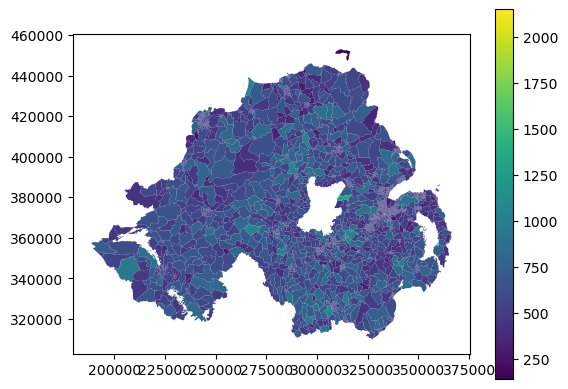

In [15]:
dz.plot(column="All usual residents", legend=True)